In [1]:
%reload_ext autoreload
%autoreload 2

In Terminal all the time
cd ~/Desktop/Thesis
source venvs/thesis_rocm/bin/activate

cd /home/virthian/Desktop/Thesis/Package/my_package/autoseqmodels
pip install -e .

In [2]:
# ---------------------------------------------------------------------------
# Path setup (so Jupyter can find the project package)
# ---------------------------------------------------------------------------
import sys
sys.path.append("/home/virthian/Desktop/Thesis/Package_Notebook")

# ---------------------------------------------------------------------------
# Standard library
# ---------------------------------------------------------------------------
import json
from pathlib import Path

# ---------------------------------------------------------------------------
# Third-party
# ---------------------------------------------------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from Models import (
    MultinomialLSTMModel,
    InferenceMultinomialLSTMModel,
    fit_model,
    compute_class_weights,
    run_optuna_study,
    mc_forecast,
    mc_compute_metrics,
    select_features_for_trial,
    select_features,

    weekly_aggregate_predictions,
)
import torch
from torch.utils.data import DataLoader, TensorDataset
import json
import numpy as np
# ---------------------------------------------------------------------------
# This project
# ---------------------------------------------------------------------------
from Data_preparation import dynamic_panel_dataset
from Models import (
    # Training
    MultinomialLSTMModel,
    fit_model,
    compute_class_weights,
    run_optuna_study,
    # Inference + Monte Carlo forecast
    InferenceMultinomialLSTMModel,
    mc_forecast,
    mc_compute_metrics,
    # Plotting / diagnostics / CSV I/O
    weekly_actuals,
    weekly_aggregate_predictions,
    plot_weekly_aggregated,
    metrics_table,
    alignment_check,
    save_predictions_to_csv,
)


# Data Loading


### Panels configuration

In [ ]:
from configs.panel_config import PanelConfig

csv_path = "Datasets/Dataset_clean/electronics_customer_week_panel.csv"

# One config object replaces DATA_CONFIG + TIME_FEATURES + FEATURE_SCHEMA + INPUT_SPEC.
cfg = PanelConfig(
    # --- identity / target ---
    id_col="Id",
    target_col="Transactions",
    frequency="weekly",
    training_start="1999-01-01", training_end="2000-12-31",
    holdout_start="2001-01-01",  holdout_end="2001-12-31",
    time_cols=("year", "week"),
    clip_target_upper=6,

    # --- cohort selection (Valendin et al.) -----------------------------------
    # True  -> keep only customers with >=1 transaction during the calibration
    #          window (equivalently, first purchase <= training_end). Customers
    #          first seen only in the holdout are dropped. Applied inside
    #          prepare_dataset, so the LSTM and the Pareto/NBD benchmark score the
    #          SAME customers (fair comparison). Set False to keep every customer.
    require_calibration_activity=True,

    # --- engineered time features (OPT-IN: omit -> none are created) ---
    time_features={"add_year_idx": True, "add_week_sin_cos": True},
    #ar_features=("period_since_last_transaction", "active_in_last_3_periods"),

    # --- feature roles (the target is target_col; don't list it here) ---
    # week_sin / week_cos are auto-added to the 'time' role from the enabled
    # flags above; year_idx is placed explicitly (a trend, not cyclical).
    known_future=("year_idx", "high.season"),
    static=("Gender", "Income"),
    observed_past=(),  # no lags or rolling stats in this example, but could add here

    # --- which columns to embed; "auto" infers cardinality from calibration ---
    #   Transactions -> clip_target_upper + 1 = 7
    #   Gender / Income -> (calibration max + 1)   (pin an int to fix the size)
    embedded_cols={"Transactions": "auto", "Gender": "auto", "Income": "auto"},
)


In [16]:
from configs.panel_config import PanelConfig

csv_path = "Datasets/Dataset_clean/electronicV2_customer_month_panel.csv"

# One config object replaces DATA_CONFIG + TIME_FEATURES + FEATURE_SCHEMA + INPUT_SPEC.
cfg = PanelConfig(
    # --- identity / target ---
    id_col="Id",
    target_col="Transactions",
    frequency="monthly",
    training_start="1999-01-01", training_end="2000-12-31",
    holdout_start="2001-01-01",  holdout_end="2001-12-31",
    time_cols=("year", "month"),
    clip_target_upper=6,

    # --- cohort selection (Valendin et al.) -----------------------------------
    # True  -> keep only customers with >=1 transaction during the calibration
    #          window (equivalently, first purchase <= training_end). Customers
    #          first seen only in the holdout are dropped. Applied inside
    #          prepare_dataset, so the LSTM and the Pareto/NBD benchmark score the
    #          SAME customers (fair comparison). Set False to keep every customer.
    require_calibration_activity=True,

    # --- engineered time features (OPT-IN: omit -> none are created) ---
    time_features={"add_year_idx": True, "add_month_sin_cos": True},
    #ar_features=("period_since_last_transaction", "active_in_last_3_periods"),

    # --- feature roles (the target is target_col; don't list it here) ---
    # month_sin / month_cos are auto-added to the 'time' role from the enabled
    # flags above; year_idx is placed explicitly (a trend, not cyclical).
    known_future=("year_idx", "high.season"),
    static=("Gender", "Income"),
    observed_past=(),  # no lags or rolling stats in this example, but could add here

    # --- which columns to embed; "auto" infers cardinality from calibration ---
    #   Transactions -> clip_target_upper + 1 = 7
    #   Gender / Income -> (calibration max + 1)   (pin an int to fix the size)
    embedded_cols={"Transactions": "auto", "Gender": "auto", "Income": "auto"},
)


### Bank

In [7]:
csv_path_trans = "Datasets/Dataset_clean/bank_customer_week_panel.csv"

# One config object replaces DATA_CONFIG + TIME_FEATURES + FEATURE_SCHEMA + INPUT_SPEC.
cfg_trans = PanelConfig(
    # --- identity / target ---
    id_col="Id",
    target_col="Transactions",
    frequency="weekly",
    training_start="1993-01-01", training_end="1994-12-31",
    holdout_start="1995-01-01",  holdout_end="1996-12-31",
    time_cols=("year", "week"),
    clip_target_upper=6,

    # --- cohort selection (Valendin et al.) -----------------------------------
    # True  -> keep only customers with >=1 transaction during the calibration
    #          window (equivalently, first purchase <= training_end). Customers
    #          first seen only in the holdout are dropped. Applied inside
    #          prepare_dataset, so the LSTM and the Pareto/NBD benchmark score the
    #          SAME customers (fair comparison). Set False to keep every customer.
    require_calibration_activity=True,

    # --- engineered time features (OPT-IN: omit -> none are created) ---
    time_features={"add_year_idx": True, "add_week_sin_cos": True},
    ar_features=("period_since_last_transaction", "active_in_last_3_periods"),

    # --- feature roles (the target is target_col; don't list it here) ---
    # week_sin / week_cos are auto-added to the 'time' role from the enabled
    # flags above; year_idx is placed explicitly (a trend, not cyclical).
    # NOTE: the trailing comma is REQUIRED to make this a 1-element tuple.
    #       ("year_idx") without it is just the string "year_idx", and the
    #       downstream code would iterate it character-by-character.
    known_future=("year"),
    static=(),
    observed_past=(),  # no lags or rolling stats in this example, but could add here

    # --- which columns to embed; "auto" infers cardinality from calibration ---
    #   Transactions -> clip_target_upper + 1 = 7
    #   Gender / Income -> (calibration max + 1)   (pin an int to fix the size)
    embedded_cols={"Transactions": "auto",},
)

In [11]:
# ---- Monte Carlo forecast settings ----------------------------------------
# Single source of truth for the holdout simulation count: every mc_forecast
# call below uses N_SIMULATIONS, so all models are compared on equal footing.
# Higher -> smoother per-customer mean, more compute. MC_SEED makes the
# forecast reproducible (same model + data + seed -> identical sampled paths).
N_SIMULATIONS = 600
MC_SEED = 42

In [17]:
# ---- 1. Build the (N, T, F) arrays from your config ----------------------
panel     = pd.read_csv(csv_path)

data_full = dynamic_panel_dataset.prepare_dataset(panel, cfg)

# ---- 2. Shape tensors for fit_model --------------------------------------
# samples : (N, T-1, F) float32
# targets : fit_model wants (B, T) long with values in [0, max_trans)
X = data_full["samples"]
y = data_full["targets"].squeeze(-1).astype(np.int64)

# max_trans comes from the RESOLVED spec prepare_dataset returns (handles 'auto').
max_trans = data_full["input_spec"]["embedded_cols"][data_full["target_col"]]
assert y.min() >= 0 and y.max() < max_trans, (
    f"Transactions in [{y.min()}, {y.max()}] but the target embedding caps at {max_trans-1}. "
    f"Raise the cardinality or clip the panel."
)

# ---- 3. Customer-wise train/val split -----------------------------------
train_idx, val_idx = train_test_split(
    np.arange(data_full["N"]), test_size=0.1, random_state=42,
)


N=829 T_CAL=24 T_HOLD=12 F=7
seq_cols   = ['Transactions', 'month_sin', 'month_cos', 'year_idx', 'high.season', 'Gender', 'Income']
target_col = 'Transactions' at index 0
calibration (829, 24, 7) | samples (829, 23, 7) | targets (829, 23, 1) | holdout (829, 12, 7)
embedded_cols = {'Transactions': 7, 'Gender': 2, 'Income': 10}


## LSTM training & hyperparameter search

### LSTM with Optuna

### Loss trials

In [18]:
# ---- 5. (Optional) class weights for focal / weighted_ce -----------------
# Skip the next two lines for the paper-faithful CE run.
LOSS_TYPE     = "cross_entropy"            # 'cross_entropy' | 'weighted_ce' | 'focal' | 'emd'
class_weights = compute_class_weights(y[train_idx], num_classes=max_trans)
print("class_weights:", class_weights.tolist())

class_weights: [0.010444901883602142, 0.2983633577823639, 0.40719565749168396, 0.8004871010780334, 1.6247509717941284, 2.52461314201355, 1.3341450691223145]


In [19]:
def data_builder(feature_config, batch_size):
      d  = select_features(data_full, feature_config)        # drop chosen cols → smaller F
      Xt = d["samples"]                                      # (N, T-1, F')
      yt = d["targets"].squeeze(-1).astype(np.int64)         # (N, T-1) class indices
      
      tr_loader = DataLoader(
          TensorDataset(torch.from_numpy(Xt[train_idx]), torch.from_numpy(yt[train_idx])),
          batch_size=batch_size, shuffle=True,
      )
      va_loader = DataLoader(
          TensorDataset(torch.from_numpy(Xt[val_idx]), torch.from_numpy(yt[val_idx])),
          batch_size=batch_size, shuffle=False,
      )   
      metadata = {                                           # the recipe to build the matching model
          "seq_cols":   d["seq_cols"],
          "input_spec": d["input_spec"],
          "target_col": d["target_col"],
          "seq_len":    Xt.shape[1],
      }   
      return tr_loader, va_loader, metadata

## Optuna optimization cross entropy

In [21]:
# ---- 7. Run the LSTM Optuna study ---------------------------------------
device = "cuda" if torch.cuda.is_available() else "cpu"
STUDY_NAME = f"lstm_{LOSS_TYPE}"            # one study per loss → no schema collisions

lstm_study = run_optuna_study(
    model_type="lstm",
    data_builder=data_builder,
    data_info={
        "n_epochs":       150,
        "patience":       7,
        "checkpoint_dir": "./checkpoints/lstm_optuna",
        "verbose":        False,
        # Loss configuration (all four read from data_info — unused keys are ignored).
        "loss_type":      LOSS_TYPE,
        "class_weights":  class_weights    # used by 'weighted_ce' / 'focal'; harmless for 'cross_entropy'
    },
    #removable_features=["Gender", "Income", "high.season", "year_idx", ("week_sin", "week_cos")],  # Optuna can drop these if it wants; the LSTM will still get the seq/time features
    removable_features=["Gender", "Income", "high.season", "year_idx", ("month_sin", "month_cos")],  # Optuna can drop these if it wants; the LSTM will still get the seq/time features
    device=device,
    n_trials=200,                            # 64 archs × 9 dropout points × 3 batches — give TPE room
    study_name=STUDY_NAME,
    summary_dir="./optuna_summaries",
    storage="sqlite:///optuna_summaries/aug_lstm_pareto.db", #new line
)

print("best trial   :", lstm_study.best_trial.number)
print("best val loss:", lstm_study.best_trial.value)
print("best params  :", lstm_study.best_trial.params)
print("checkpoint   :", lstm_study.best_trial.user_attrs["checkpoint_path"])

[I 2026-05-31 19:04:29,690] A new study created in RDB with name: lstm_cross_entropy_20260531_1904
[I 2026-05-31 19:04:51,160] Trial 0 finished with value: 0.3688368946313858 and parameters: {'hidden_dim': 128, 'memory_units': 32, 'dense_units': 64, 'dropout': 0.2832290311184182, 'learning_rate': 0.00010725209743172001, 'weight_decay': 0.00757947995334801, 'batch_size': 64, 'use_Gender': False, 'use_Income': True, 'use_high.season': False, 'use_year_idx': False, 'use_month_sin+month_cos': False}. Best is trial 0 with value: 0.3688368946313858.
[I 2026-05-31 19:04:55,832] Trial 1 finished with value: 0.3789077699184418 and parameters: {'hidden_dim': 64, 'memory_units': 128, 'dense_units': 128, 'dropout': 0.38625281322982374, 'learning_rate': 0.0015635108708133452, 'weight_decay': 1.6536937182824424e-05, 'batch_size': 128, 'use_Gender': False, 'use_Income': False, 'use_high.season': False, 'use_year_idx': False, 'use_month_sin+month_cos': True}. Best is trial 0 with value: 0.368836894631

best trial   : 187
best val loss: 0.3553764671087265
best params  : {'hidden_dim': 64, 'memory_units': 128, 'dense_units': 64, 'dropout': 0.2630660723636739, 'learning_rate': 0.0023450145479719103, 'weight_decay': 3.533724685341848e-05, 'batch_size': 64, 'use_Gender': True, 'use_Income': False, 'use_high.season': True, 'use_year_idx': True, 'use_month_sin+month_cos': True}
checkpoint   : checkpoints/lstm_optuna/lstm_cross_entropy_20260531_1904/lstm_trial_187.pth


### Optuna fancy

In [9]:
# ---- 7. Run the LSTM Optuna study ---------------------------------------
device = "cuda" if torch.cuda.is_available() else "cpu"
STUDY_NAME = f"lstm_{LOSS_TYPE}_rollout_composite"            # one study per loss → no schema collisions

lstm_study = run_optuna_study(
    model_type="lstm",
    selection_metric="rollout_composite",  # new line: optimize the metric we actually care about, not just val loss
    rollout_data=data_full,                        # new line: pass the full data for the rollout metric; the study will split it internally
    val_idx=val_idx,                                # new line: pass val_idx so the study can compute the rollout metric on the same customers as the val loss
    rollout_horizon=52,
    rollout_n_simulations=100,
    data_builder=data_builder,
    data_info={
        "n_epochs":       150,
        "patience":       7,
        "checkpoint_dir": "./checkpoints/lstm_optuna",
        "verbose":        False,
        # Loss configuration (all four read from data_info — unused keys are ignored).
        "loss_type":      LOSS_TYPE,
        "class_weights":  class_weights    # used by 'weighted_ce' / 'focal'; harmless for 'cross_entropy'
    },
    removable_features=["Gender", "Income", "high.season", "year_idx", ("week_sin", "week_cos")],  # Optuna can drop these if it wants; the LSTM will still get the seq/time features
    device=device,
    n_trials=200,                            # 64 archs × 9 dropout points × 3 batches — give TPE room
    study_name=STUDY_NAME,
    summary_dir="./optuna_summaries",
    storage="sqlite:///optuna_summaries/aug_lstm_pareto.db", #new line
)

print("best trial   :", lstm_study.best_trial.number)
print("best val loss:", lstm_study.best_trial.value)
print("best params  :", lstm_study.best_trial.params)
print("checkpoint   :", lstm_study.best_trial.user_attrs["checkpoint_path"])

[I 2026-05-31 16:38:38,066] A new study created in RDB with name: lstm_cross_entropy_rollout_composite_20260531_1638
[I 2026-05-31 16:39:38,612] Trial 0 finished with value: 1.526076799881897 and parameters: {'hidden_dim': 128, 'memory_units': 32, 'dense_units': 64, 'dropout': 0.2832290311184182, 'learning_rate': 0.00010725209743172001, 'weight_decay': 0.00757947995334801, 'batch_size': 64, 'use_Gender': False, 'use_Income': True, 'use_high.season': False, 'use_year_idx': False, 'use_week_sin+week_cos': False}. Best is trial 0 with value: 1.526076799881897.
[I 2026-05-31 16:40:05,375] Trial 1 finished with value: 1.3122733482125655 and parameters: {'hidden_dim': 64, 'memory_units': 128, 'dense_units': 128, 'dropout': 0.38625281322982374, 'learning_rate': 0.0015635108708133452, 'weight_decay': 1.6536937182824424e-05, 'batch_size': 128, 'use_Gender': False, 'use_Income': False, 'use_high.season': False, 'use_year_idx': False, 'use_week_sin+week_cos': True}. Best is trial 1 with value: 1.

best trial   : 103
best val loss: 1.2325153778816742
best params  : {'hidden_dim': 128, 'memory_units': 128, 'dense_units': 128, 'dropout': 0.2035347898109841, 'learning_rate': 0.00172435092181986, 'weight_decay': 2.0930237576443755e-05, 'batch_size': 64, 'use_Gender': False, 'use_Income': False, 'use_high.season': True, 'use_year_idx': True, 'use_week_sin+week_cos': True}
checkpoint   : checkpoints/lstm_optuna/lstm_cross_entropy_rollout_composite_20260531_1638/lstm_trial_103.pth


In [22]:
# ---- 8. Rebuild the LSTM with the Optuna-selected arch + load weights ----
best        = lstm_study.best_trial
best_params = lstm_study.best_trial.params
CHECKPOINT  = lstm_study.best_trial.user_attrs["checkpoint_path"]
data_best = select_features_for_trial(data_full, best)
inference_model = InferenceMultinomialLSTMModel(
    seq_cols=data_best["seq_cols"],
    input_spec=data_best["input_spec"],
    target_col=data_best["target_col"],
    hidden_dim=best_params["hidden_dim"],
    memory_units=best_params["memory_units"],
    dense_units=best_params["dense_units"],
    dropout=best_params["dropout"],
    mode="sample",
)
inference_model.load_state_dict(torch.load(CHECKPOINT, map_location="cpu"))

<All keys matched successfully>

In [23]:
# ---- 9. Valendin-style autoregressive MC forecast ------------------------
forecast = mc_forecast(
    inference_model,
    data_best,
    n_simulations=N_SIMULATIONS,
    device=device,
    seed=MC_SEED,
)

# Guard against a stale (not-re-run) cell silently reporting an old count.
assert forecast["simulations"].shape[0] == forecast["n_simulations"] == N_SIMULATIONS

print("simulations shape:", forecast["simulations"].shape)        # (S, N, T_HOLD)
print("prediction mean  :", forecast["prediction_mean"].shape)    # (N, T_HOLD)
print("actual (real)    :", forecast["actual"].shape)             # (N, T_HOLD)

simulations shape: (600, 829, 12)
prediction mean  : (829, 12)
actual (real)    : (829, 12)


In [24]:
# ---- 10. Score + sanity check -------------------------------------------
metrics = mc_compute_metrics(forecast["actual"], forecast["prediction_mean"])
print(metrics)

# Aggregate predicted vs actual per week (useful for the thesis plot).
agg_pred   = forecast["prediction_mean"].sum(axis=0)              # (T_HOLD,)
agg_actual = forecast["actual"].sum(axis=0)
for i in range(min(20, len(agg_pred))):
    print(f"  week {i:>2}  pred={agg_pred[i]:6.1f}  actual={agg_actual[i]:6.1f}")

{'rmse': 0.8305866651652943, 'bias_percent': 13.589070698445703, 'mape_aggregate_style': 25.942399422812702}
  week  0  pred= 208.2  actual= 234.0
  week  1  pred= 143.7  actual= 146.0
  week  2  pred= 134.8  actual=  69.0
  week  3  pred= 125.1  actual=  75.0
  week  4  pred= 119.4  actual=  89.0
  week  5  pred= 118.0  actual=  93.0
  week  6  pred= 116.7  actual= 133.0
  week  7  pred= 117.9  actual=  96.0
  week  8  pred= 116.4  actual=  75.0
  week  9  pred= 123.4  actual=  68.0
  week 10  pred= 131.7  actual= 151.0
  week 11  pred= 211.0  actual= 238.0


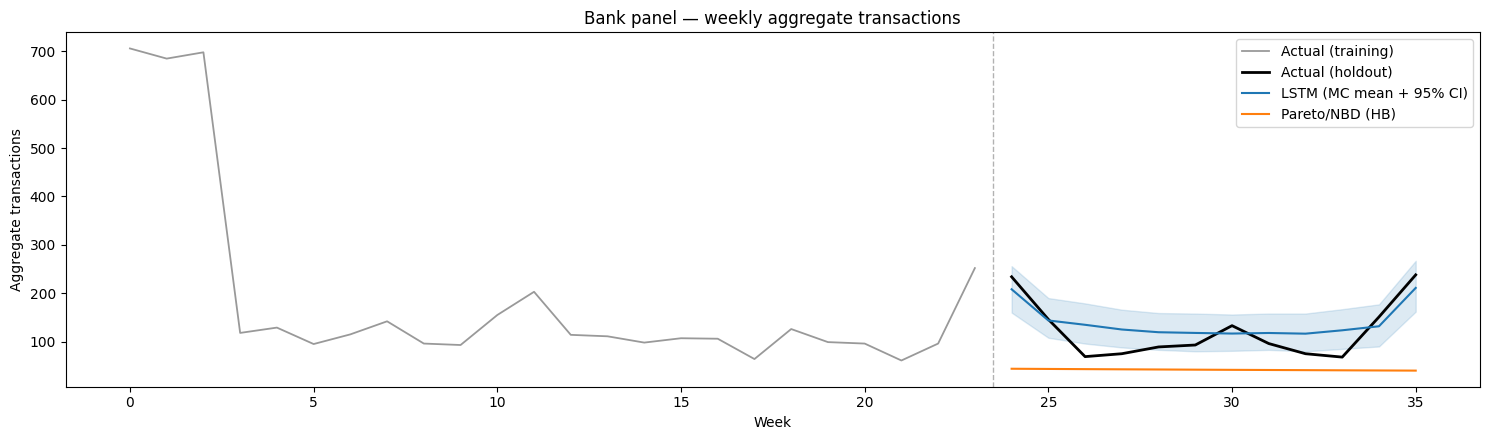

In [25]:
# Aggregate actuals across customers per holdout week.
actuals = forecast["actual"].sum(axis=0)            # (T_HOLD,)

# (Optional) training-window aggregate to show context to the left of the holdout.
# data_full["calibration"] is (N, T_CAL, F); the target column lives at target_idx.
target_idx    = data_full["seq_cols"].index(data_full["target_col"])
train_actuals = data_full["calibration"][..., target_idx].sum(axis=0)   # (T_CAL,)

# Add a trailing 1-axis so weekly_aggregate_predictions takes the (S, N, T, 1)
# branch and draws the 95% MC ribbon.
mc_sims = forecast["simulations"][..., None]        # (S, N, T_HOLD, 1)

fig, ax = plot_weekly_aggregated(
				actuals=actuals,
    data=data_best,
    pareto_paper_benchmark=True,      
				predictions_by_model={"LSTM (MC mean + 95% CI)": mc_sims},
				train_actuals=train_actuals,                    # omit to plot only the holdout
				title="Bank panel — weekly aggregate transactions",
				show_ci=True,
				# save_path="figures/bank_lstm_weekly.png",    # uncomment to save
)


In [25]:
tbl = metrics_table(
				forecast["actual"],
				{"LSTM": forecast["simulations"][..., None]},
				pareto_nbd_benchmark=True,
				pareto_paper_benchmark=True,
				data=data_best,
)
print(tbl)

/home/virthian/Desktop/Thesis/venvs/thesis_rocm/lib/python3.12/site-packages/scipy/optimize/_optimize.py:869: RuntimeWarning: invalid value encountered in subtract
  np.max(np.abs(fsim[0] - fsim[1:])) <= fatol):


                     rmse  bias_percent  mape_aggregate_style
model                                                        
LSTM             0.375428      3.925358             46.359805
Pareto/NBD       0.375447    -57.790016             62.245531
Pareto/NBD (HB)  0.375823    -62.641629             65.379948


In [27]:
import numpy as np
from Models.plot_utils import _pareto_from_data
A   = forecast["actual"].sum()                     # total actual holdout tx
L   = forecast["simulations"].mean(0).sum()        # LSTM total
P   = _pareto_from_data(data_best, "mle").sum()    # Pareto MLE total
H   = _pareto_from_data(data_best, "paper").sum()  # Pareto HB total
print(f"actual={A:.0f}  LSTM={L:.0f}  Pareto={P:.0f}  HB={H:.0f}")
print(f"calib total/wk={data_best['calibration'][...,0].sum()/data_best['calibration'].shape[1]:.0f}  "
						f"holdout total/wk={A/forecast['actual'].shape[1]:.0f}")


/home/virthian/Desktop/Thesis/venvs/thesis_rocm/lib/python3.12/site-packages/scipy/optimize/_optimize.py:869: RuntimeWarning: invalid value encountered in subtract
  np.max(np.abs(fsim[0] - fsim[1:])) <= fatol):


actual=1467  LSTM=1525  Pareto=712  HB=548
calib total/wk=45  holdout total/wk=28
